In [8]:
from test_on_data.test_on_data import main
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from pathlib import Path

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7055.75it/s]
BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.




Running Now, Please wait...
Topic Accuracy: 0.840000
Emotion Micro F1: 0.373444
Emotion Macro F1: 0.323040
Emotion Accuracy: 0.280000
Total Accuracy: 0.230000
saved predictions to /Users/nate/Classes/COMPSCI175/CAN/Src/test_on_data/results.json


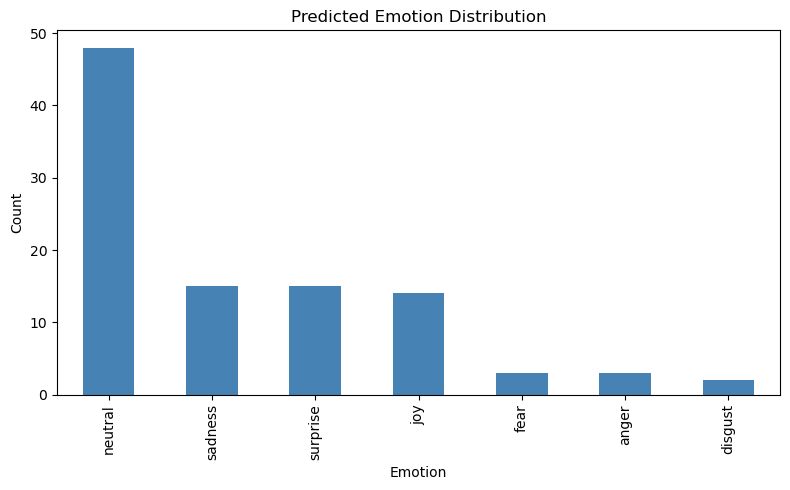

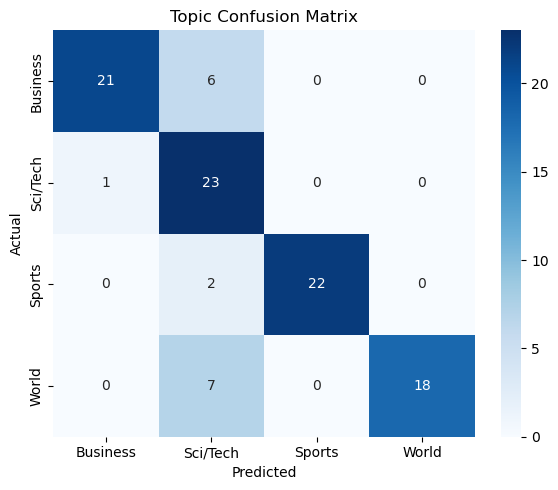

In [12]:
# Run the test inference on the synthetic data using BERT
#  The data is saved to "test_on_data/results.json"

# IMPORTANT: Change the number passed below to control how many samples are used for testing
# You can enter up to 2,497
# We used 50 for demonstration purposes of our pipeline
main(100)

# Open the results and load them into a dataframe
output_dir = Path("test_on_data")
with open(output_dir / "results.json") as f:
    results = json.load(f)

results["metrics"]
predictions = results["predictions"]
df = pd.DataFrame(predictions)
df.head()
plt.figure(figsize=(8,5))

df["pred_emotions_ekman"].explode().value_counts().plot(kind="bar",color="steelblue")

# Plot the predicted emotion distribution
plt.title("Predicted Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(output_dir / "emotion_distribution.png", dpi=300)
plt.show()

# Plot the topic confusion matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(df["true_topic"], df["pred_topic"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=cm.shape[0] and sorted(df["pred_topic"].unique()),
    yticklabels=cm.shape[0] and sorted(df["true_topic"].unique()))

plt.title("Topic Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(output_dir / "topic_confusion_matrix.png", dpi=300)
plt.show()